In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from src.data.paths import project_dir
import pandas as pd

In [2]:
merged_image = np.load('merged_image_data.npz')['merged_image']

In [3]:
df_w = pd.read_csv( 'x_profil_p2.dat', delim_whitespace=True, names=['X_mm', 'Dose', 'Err'])
df_w = df_w[ df_w['X_mm'] <= 0 ]
df_w['X_mm'] -= df_w['X_mm'].min()
df_w['X_mm'] *= 10
df_w['X_mm'] -= 2
df_w['Dose'] /= df_w['Dose'].max()
df_w.head()

/tmp/ipykernel_110756/706978658.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_w = pd.read_csv( 'x_profil_p2.dat', delim_whitespace=True, names=['X_mm', 'Dose', 'Err'])


,X_mm,Dose,Err
0,-2.0,0.247462,0.001441
1,-1.9,0.242590,0.001500
2,-1.8,0.247083,0.001407
3,-1.7,0.242681,0.001468
4,-1.6,0.246944,0.001531


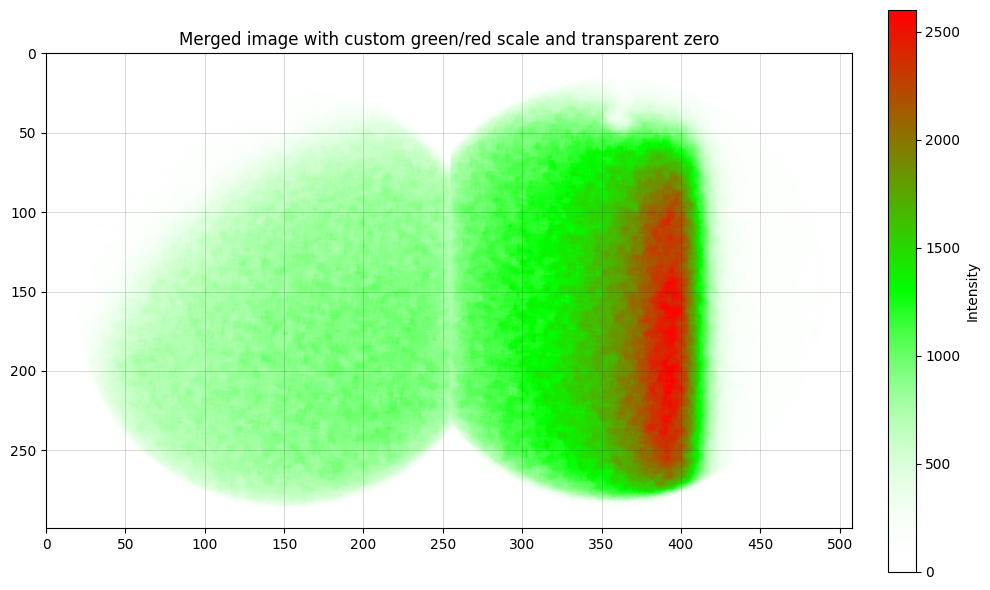

In [4]:


# Build colormap: 0 -> white with alpha 0, 1300 -> green, 2600 -> red
vmin, vmax = 0, 2600
cmap_merge = LinearSegmentedColormap.from_list(
    'merge_cmap',
    [
        (0.0, (1.0, 1.0, 1.0, 0.0)),      # 0 -> transparent white
        (1300.0 / vmax, (0.0, 1.0, 0.0, 1.0)),  # 1300 -> green
        (1.0, (1.0, 0.0, 0.0, 1.0)),      # 2600 -> red
    ]
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_facecolor('white')  # ensure transparency shows as white

im = ax.imshow(merged_image, cmap=cmap_merge, vmin=vmin, vmax=vmax)
ax.set_title('Merged image with custom green/red scale and transparent zero')

# Thin grid lines every 50 px
h, w = merged_image.shape
ax.set_xticks(np.arange(0, w + 1, 50))
ax.set_yticks(np.arange(0, h + 1, 50))
ax.grid(True, which='both', color='k', alpha=0.2, linewidth=0.5)
ax.set_xlim(0, w-1)
ax.set_ylim(h-1, 0)

# Optional colorbar (vmax fixed to 2600)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Intensity')

plt.tight_layout()
plt.show()

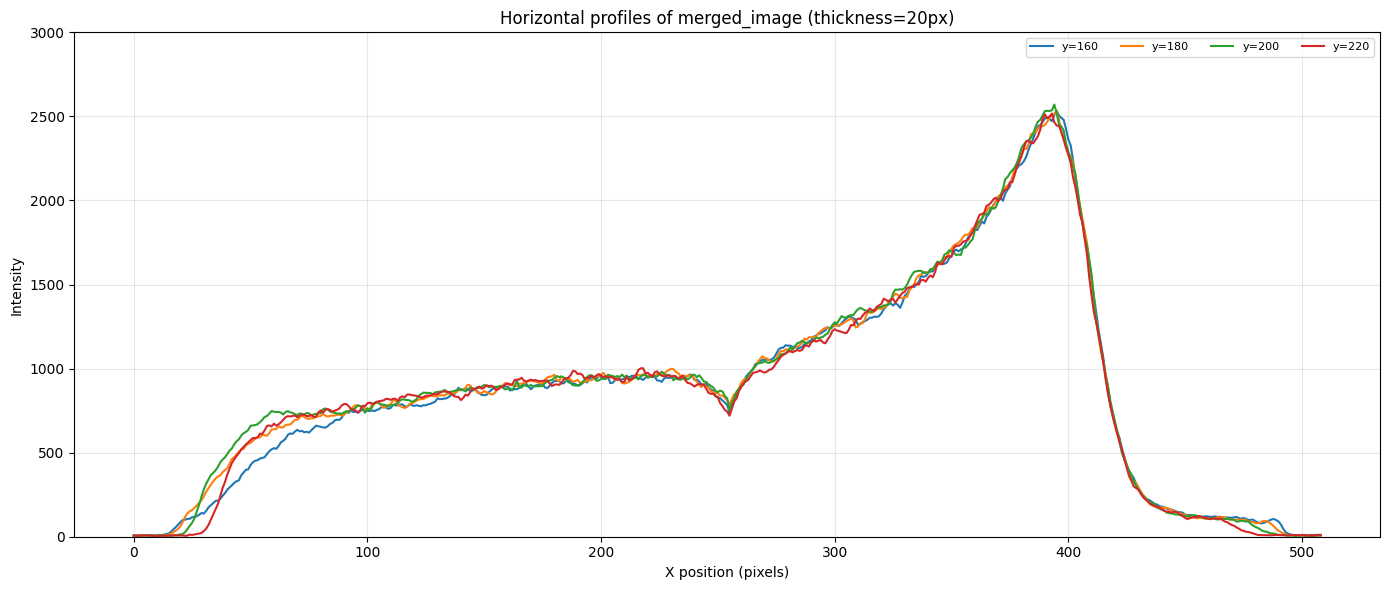

In [5]:
thickness = 20  # px
y_positions = range(160, 221, 20)  # 60, 80, 100, ..., 220

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

h, w = merged_image.shape
for y in y_positions:
    y0 = max(0, int(y - thickness // 2))
    y1 = min(h, int(y + thickness // 2))
    # average a horizontal stripe [y0:y1) across rows to get 1D profile along X
    stripe = merged_image[y0:y1, :].astype(float)
    profile = np.nanmean(stripe, axis=0)
    ax.plot(profile, label=f'y={y}')

ax.set_xlabel('X position (pixels)')
ax.set_ylabel('Intensity')
ax.set_title(f'Horizontal profiles of merged_image (thickness={thickness}px)')
ax.set_ylim(0, 3000)
ax.grid(True, alpha=0.3)
ax.legend(ncols=4, fontsize=8)
plt.tight_layout()
plt.show()

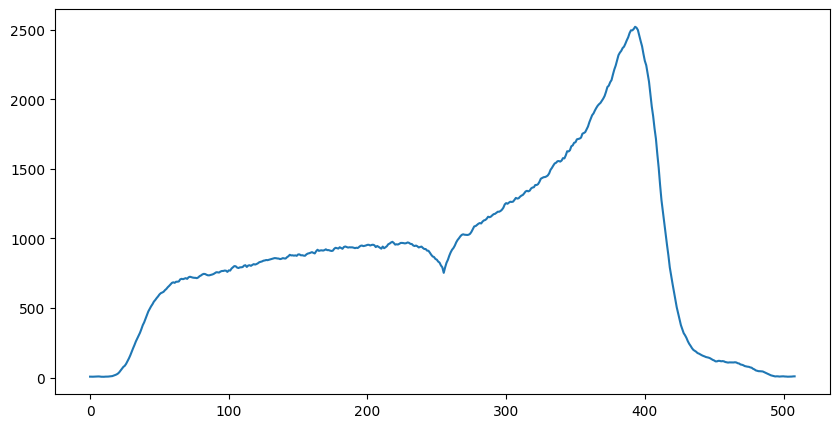

In [6]:
stripe = merged_image[170:230, :].astype(float)
profile = np.nanmean(stripe, axis=0)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(profile, label=f'y=170:230')

In [7]:

base_path = project_dir / 'data' / 'raw'
base_path.exists()
article_plots_path = base_path / r"article-plots.h5"
df_bp_exp = pd.read_hdf(article_plots_path, key='bp_exp')
df_bp_mc = pd.read_hdf(article_plots_path, key='bp_mc')

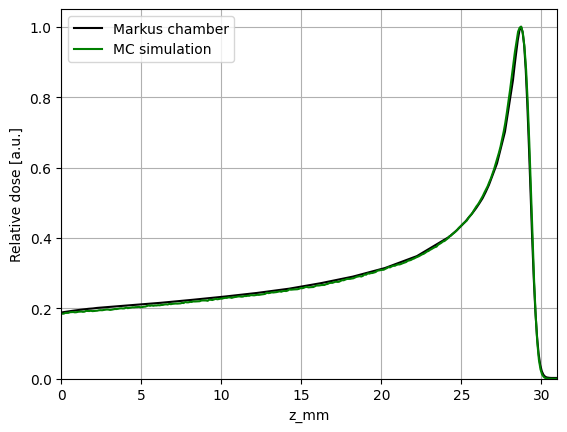

In [8]:
fig, ax = plt.subplots(nrows=1, sharex=True)
df_bp_exp.plot(ax=ax, x='Depth', y='Signal', label='Markus chamber', color='black', style='-')
df_bp_mc.plot(ax=ax, x='z_mm', y='dose', label='MC simulation', color='green', style='-')
ax.set_ylim(0,1.05)
ax.set_xlim(0, 31)
ax.grid()
ax.set_ylabel("Relative dose [a.u.]");

In [9]:
px_to_mm = 0.074

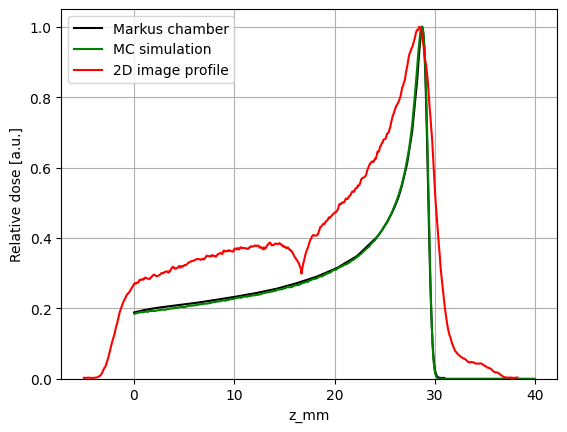

In [10]:
#px_to_mm = 0.07211249531663806

x_for_2d_image = 1.15*np.arange(stop=len(profile)) * px_to_mm - 5
y_for_2d_image = profile / np.max(profile)

fig, ax = plt.subplots(nrows=1, sharex=True)
df_bp_exp.plot(ax=ax, x='Depth', y='Signal', label='Markus chamber', color='black', style='-')
df_bp_mc.plot(ax=ax, x='z_mm', y='dose', label='MC simulation', color='green', style='-')
ax.plot(x_for_2d_image, y_for_2d_image, label='2D image profile', color='red')
ax.set_ylim(0,1.05)
#ax.set_xlim(0, 31)
ax.grid()
ax.set_ylabel("Relative dose [a.u.]");
ax.legend();

In [11]:
# calculate y_for_2d_image at the point where x_for_2d_image == 5 mm
x_target = 11.0  # mm
index_closest = (np.abs(x_for_2d_image - x_target)).argmin()
y_at_match = y_for_2d_image[index_closest]

# calculate the same for Markus chamber data
y_markus_at_match = df_bp_exp.loc[df_bp_exp['Depth'].sub(x_target).abs().idxmin(), 'Signal']
y_wedge_at_match = df_w.loc[df_w['X_mm'].sub(x_target).abs().idxmin(), 'Dose']

ratio = y_wedge_at_match / y_at_match
ratio

np.float64(0.7516059184667508)

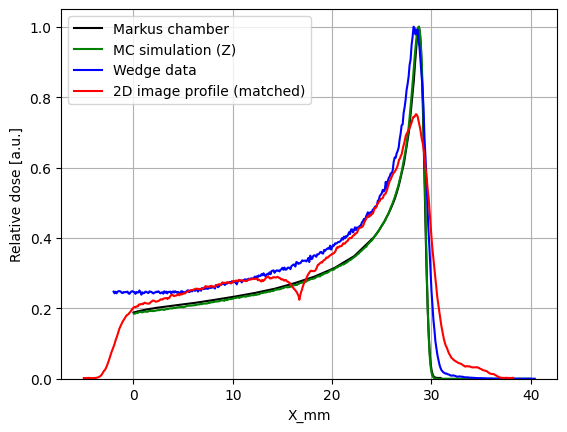

In [12]:
y_matched = y_for_2d_image * ratio

fig, ax = plt.subplots(nrows=1, sharex=True)
df_bp_exp.plot(ax=ax, x='Depth', y='Signal', label='Markus chamber', color='black', style='-')
df_bp_mc.plot(ax=ax, x='z_mm', y='dose', label='MC simulation (Z)', color='green', style='-')
df_w.plot(ax=ax, x='X_mm', y='Dose', label='Wedge data', color='blue', style='-')
ax.plot(x_for_2d_image, y_matched, label='2D image profile (matched)', color='red')
ax.set_ylim(0,1.05)
#ax.set_xlim(0, 31)
ax.grid()
ax.set_ylabel("Relative dose [a.u.]");
ax.legend();

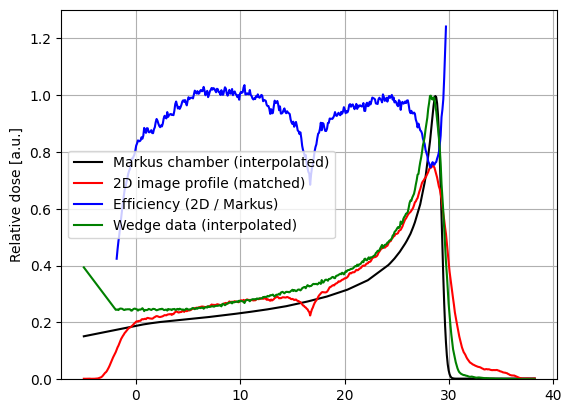

In [13]:
# create interpolation function for Markus chamber data

from scipy.interpolate import interp1d
interp_markus = interp1d(df_bp_exp['Depth'], df_bp_exp['Signal'], kind='linear', fill_value="extrapolate")
interp_wedge = interp1d(df_w['X_mm'], df_w['Dose'], kind='linear', fill_value="extrapolate")

y_markus = interp_markus(x_for_2d_image)
y_wedge = interp_wedge(x_for_2d_image)  


efficiency = y_matched / y_wedge
efficiency[efficiency > 1.3] = np.nan
efficiency[y_markus < 0.05] = np.nan  
efficiency[y_matched < 0.1] = np.nan



fig, ax = plt.subplots(nrows=1, sharex=True)
ax.plot(x_for_2d_image, y_markus, label='Markus chamber (interpolated)', color='black')
ax.plot(x_for_2d_image, y_matched, label='2D image profile (matched)', color='red')
ax.plot(x_for_2d_image, efficiency, label='Efficiency (2D / Markus)', color='blue')
ax.plot(x_for_2d_image, y_wedge, label='Wedge data (interpolated)', color='green')

ax.set_ylim(0,1.3)
#ax.set_xlim(25, 31)
ax.grid()
ax.set_ylabel("Relative dose [a.u.]");
ax.legend();

<Axes: xlabel='X_mm'>

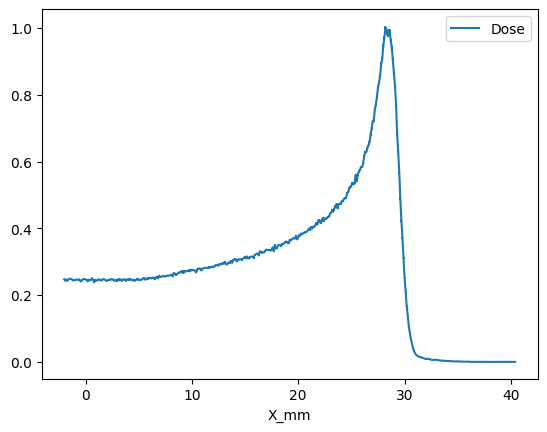

In [14]:
df_w.plot( x='X_mm', y='Dose', yerr='Err', kind='line' )

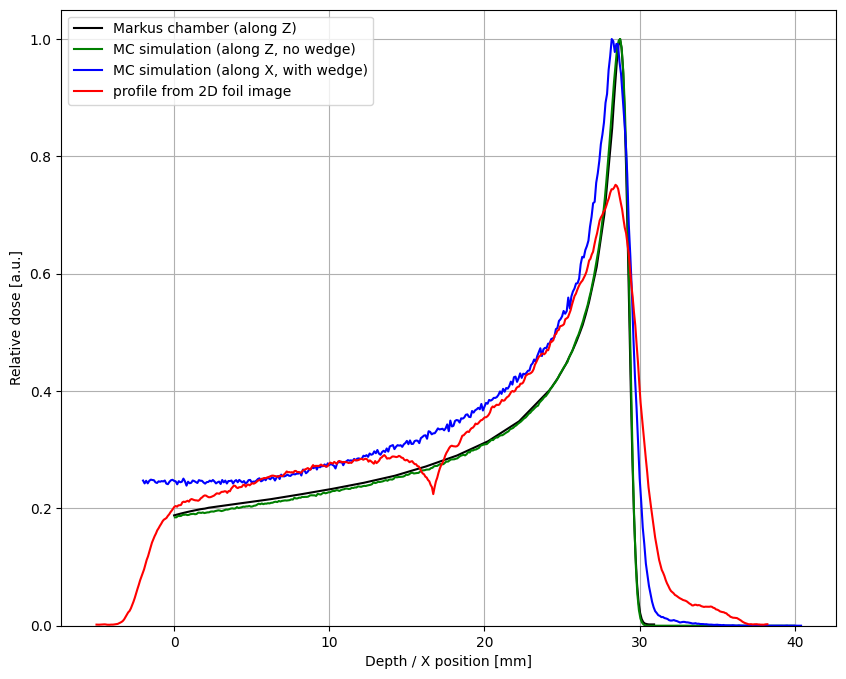

In [26]:
fig, ax = plt.subplots(nrows=1, sharex=True, figsize=(10, 8))
df_bp_exp.plot(ax=ax, x='Depth', y='Signal', label='Markus chamber (along Z)', color='black', style='-')
df_bp_mc.plot(ax=ax, x='z_mm', y='dose', label='MC simulation (along Z, no wedge)', color='green', style='-')
df_w.plot( ax=ax, x='X_mm', y='Dose', label='MC simulation (along X, with wedge)', color='blue' )
ax.plot(x_for_2d_image, y_matched, label='profile from 2D foil image', color='red')
ax.set_ylim(0,1.05)
#ax.set_xlim(0, 31)
ax.grid()
ax.set_xlabel("Depth / X position [mm]");
ax.set_ylabel("Relative dose [a.u.]");
ax.legend();